<a href="https://colab.research.google.com/github/rijuvanak/Project/blob/main/gflownet/MOLECULAR_CHEMICAL_SPACE_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total molecules: 200


[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerator
[18:16:36] DEPRECATION WARNING: please use MorganGenerat

Valid molecules: 200


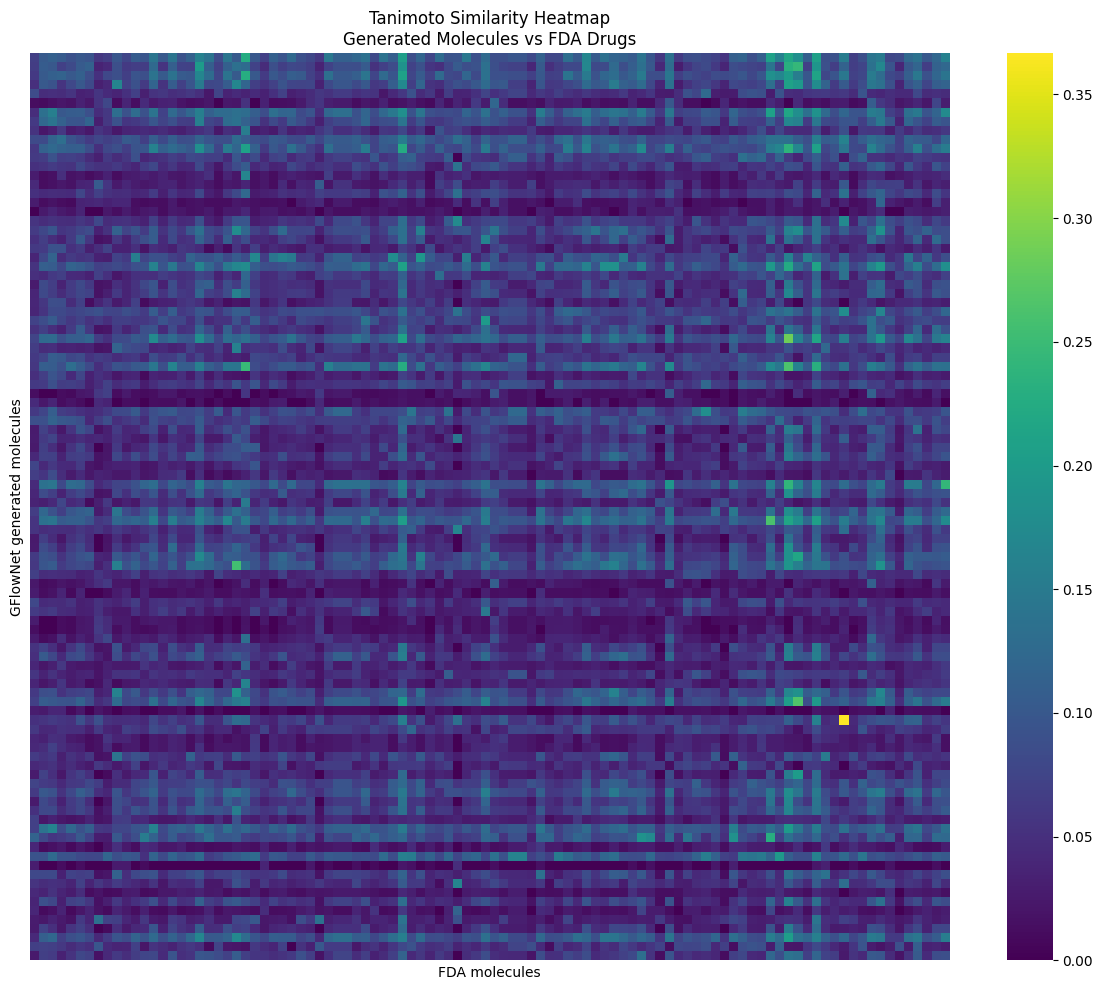

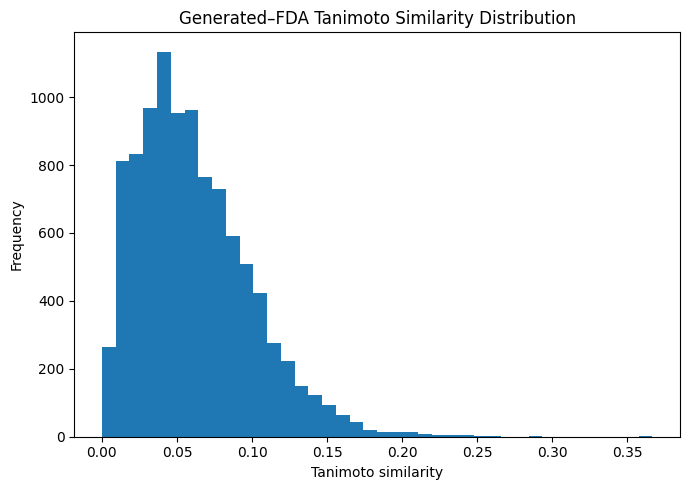

Top similarity pairs saved


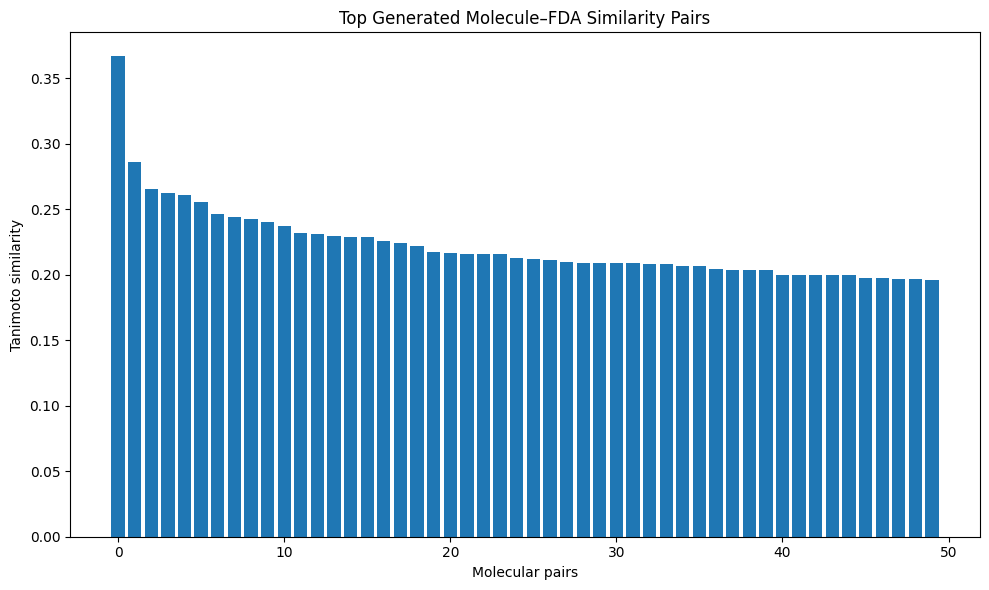

k= 3 Silhouette= 0.06384883717622179
k= 4 Silhouette= 0.059136916239080156
k= 5 Silhouette= 0.059302915010347415
k= 6 Silhouette= 0.05586866538759411
k= 7 Silhouette= 0.05563256780290722
k= 8 Silhouette= 0.05387571210316332
k= 9 Silhouette= 0.0658423050689628
k= 10 Silhouette= 0.07067184124838378


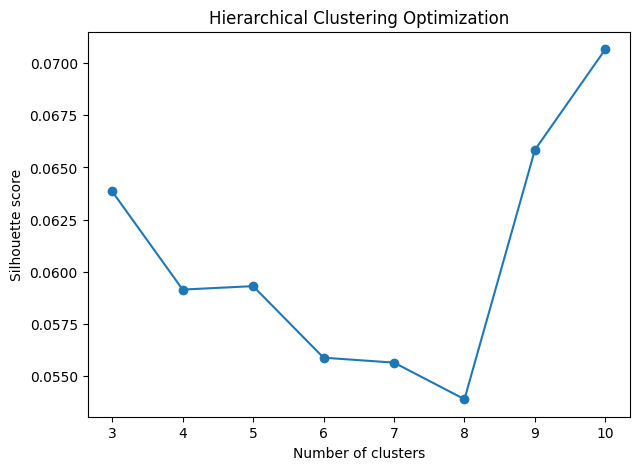

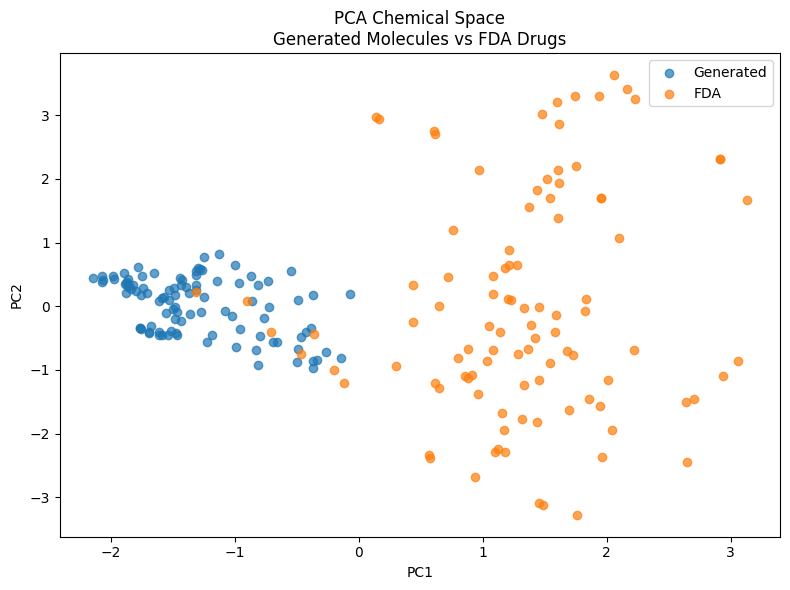

/tmp/ipykernel_1478/22362785.py:655: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z=linkage(


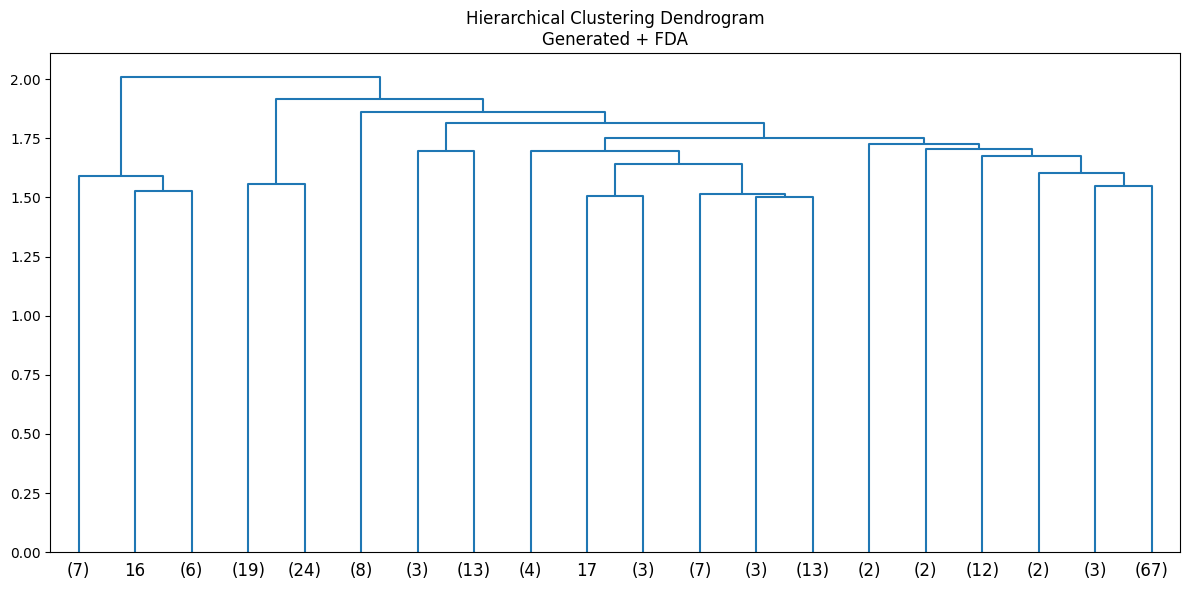


ALL GENERATED-FDA RESULTS SAVED IN: Generated_FDA_results


In [ ]:
# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs FDA Drugs
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"
FDA_FILE = "/content/TOP100 fda.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_FDA_results")
OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


fda = pd.read_csv(
    FDA_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)


fda_smiles = (
    fda[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = generated_smiles + fda_smiles


sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["FDA"] * len(fda_smiles)
)



print("Total molecules:",len(all_smiles))



# ============================================================
# MORGAN FINGERPRINT GENERATION
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]
valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):

    fp,arr=get_fp(smi)


    if fp is not None:

        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)



X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)



# ============================================================
# Tanimoto Similarity Matrix
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )



# ============================================================
# GENERATED vs FDA HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


fda_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="FDA"
]



generated_fda_matrix = similarity[
    np.ix_(
        generated_ids,
        fda_ids
    )
]



plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_fda_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "FDA molecules"
)


plt.ylabel(
    "GFlowNet generated molecules"
)


plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs FDA Drugs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_fda_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)


plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–FDA Tanimoto Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-FDA SIMILARITY PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in fda_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "FDA_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_FDA_pairs.xlsx",
    index=False
)



print(
    "Top similarity pairs saved"
)




# ============================================================
# TOP PAIRS BAR GRAPH
# ============================================================



top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "FDA"
    ]
)



plt.figure(
    figsize=(10,6)
)



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)


plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–FDA Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_FDA_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )


    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    cluster_df=pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    )



    cluster_df.to_excel(
        OUTPUT_DIR/f"Generated_FDA_clusters_k{k}.xlsx",
        index=False
    )



# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================



pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")


plt.title(
    "PCA Chemical Space\nGenerated Molecules vs FDA Drugs"
)


plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_FDA.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================



Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + FDA"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL GENERATED-FDA RESULTS SAVED IN:",
    OUTPUT_DIR
)

In [ ]:
# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs NF-kB Active Molecules
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Similarity heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"

NFKB_FILE = "/content/top 100 actives.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_NFkB_results")

OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


nfkb = pd.read_csv(
    NFKB_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



nfkb_smiles = (
    nfkb[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = (
    generated_smiles
    +
    nfkb_smiles
)



sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["NF-kB_Active"] * len(nfkb_smiles)
)



print(
    "Total molecules:",
    len(all_smiles)
)




# ============================================================
# MORGAN FINGERPRINT
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]

valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):


    fp,arr=get_fp(smi)


    if fp is not None:


        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)




X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)




# ============================================================
# TANIMOTO SIMILARITY MATRIX
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )




# ============================================================
# GENERATED vs NF-kB HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


nfkb_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="NF-kB_Active"
]



generated_nfkb_matrix = similarity[
    np.ix_(
        generated_ids,
        nfkb_ids
    )
]




plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_nfkb_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "NF-kB active molecules"
)



plt.ylabel(
    "GFlowNet generated molecules"
)



plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs NF-kB Active Compounds"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_nfkb_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)



plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–NF-kB Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-NFkB PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in nfkb_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "NFkB_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs.xlsx",
    index=False
)



print(
    "Top Generated-NFkB pairs saved"
)




# ============================================================
# TOP PAIR BAR PLOT
# ============================================================


top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "NFkB"
    ]
)



plt.figure(figsize=(10,6))



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)



plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–NF-kB Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )



    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    ).to_excel(
        OUTPUT_DIR/f"Generated_NFkB_clusters_k{k}.xlsx",
        index=False
    )




# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================


pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")



plt.title(
    "PCA Chemical Space\nGenerated vs NF-kB Active"
)



plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_NFkB.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================


Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + NF-kB"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL Generated-NFkB RESULTS SAVED IN:",
    OUTPUT_DIR
)

ModuleNotFoundError: No module named 'rdkit'

Total molecules: 200
Valid molecules: 200


[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerator
[11:50:52] DEPRECATION WARNING: please use MorganGenerat

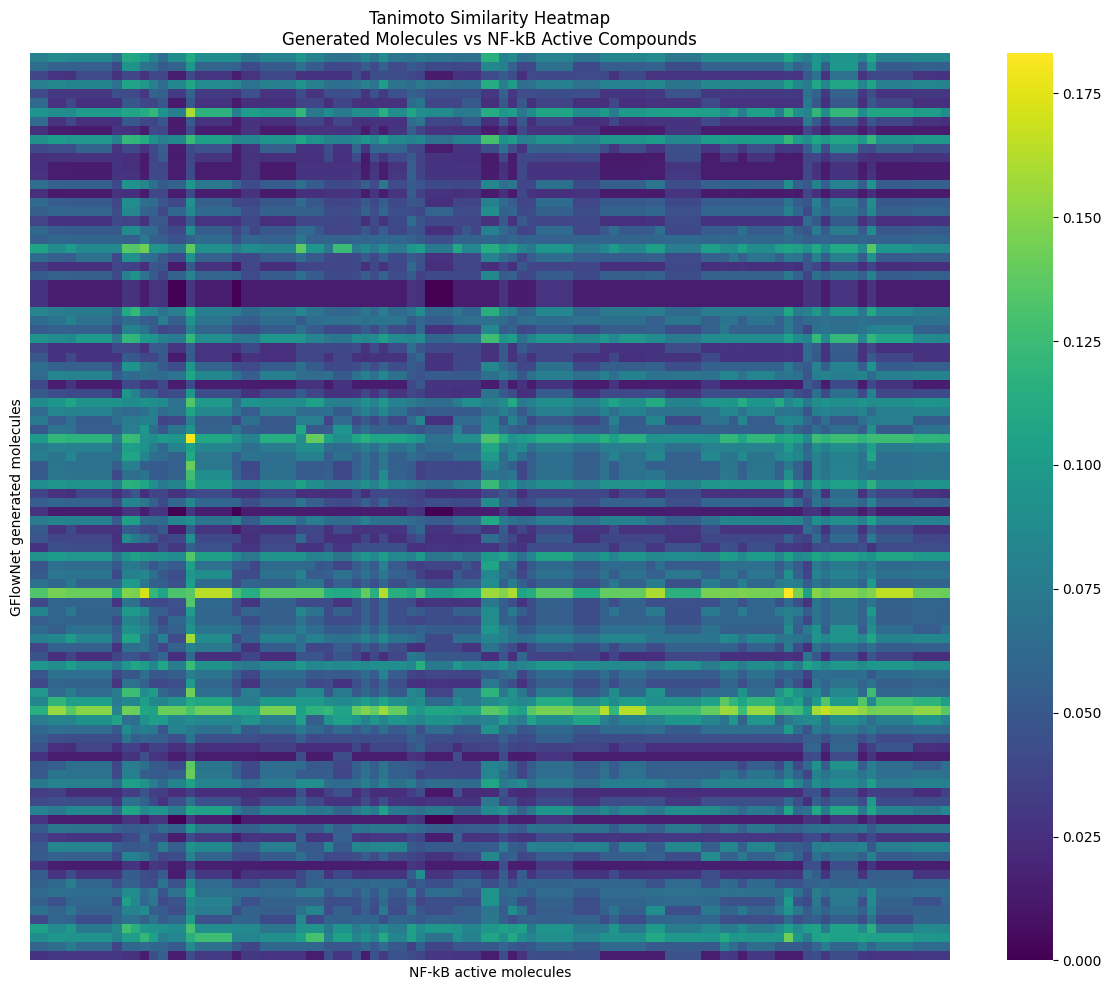

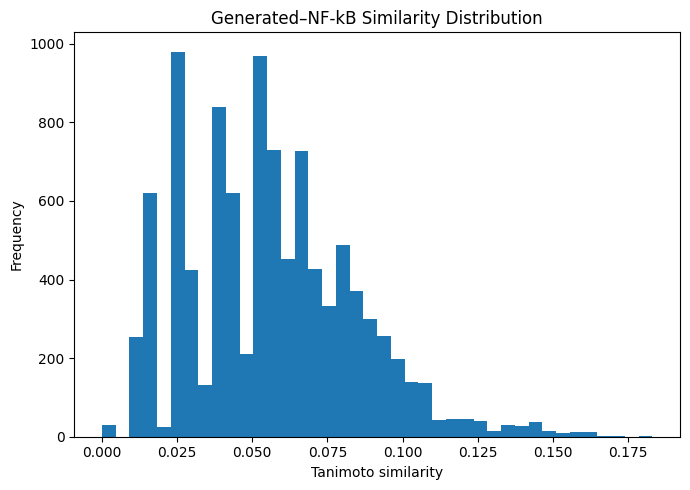

Top Generated-NFkB pairs saved


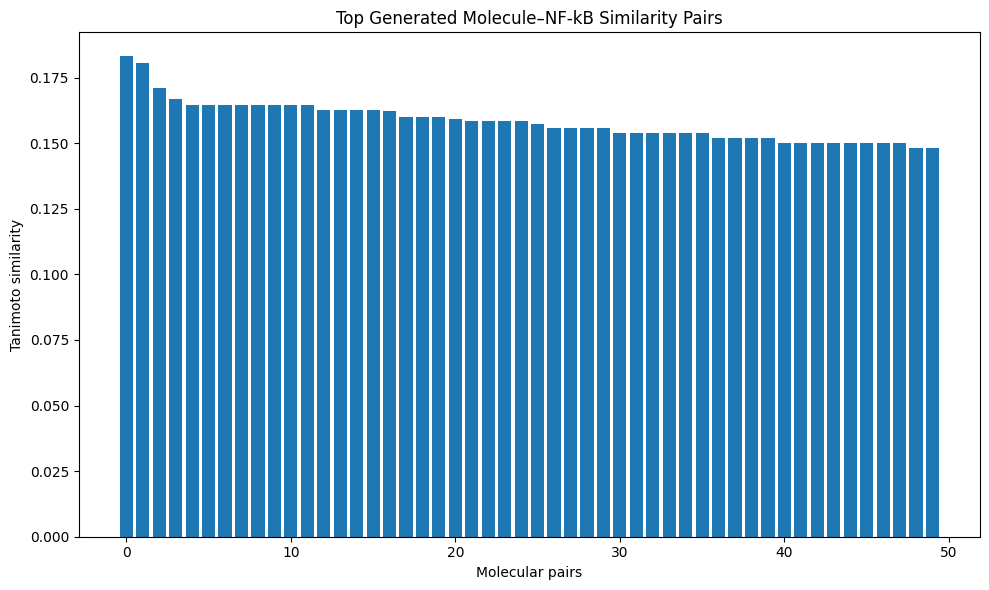

k= 3 Silhouette= 0.24339610988157656
k= 4 Silhouette= 0.23343638053730295
k= 5 Silhouette= 0.22789761879551831
k= 6 Silhouette= 0.2409014967728527
k= 7 Silhouette= 0.20691349828654992
k= 8 Silhouette= 0.20711326031948846
k= 9 Silhouette= 0.21116123376283327
k= 10 Silhouette= 0.2123067454064231


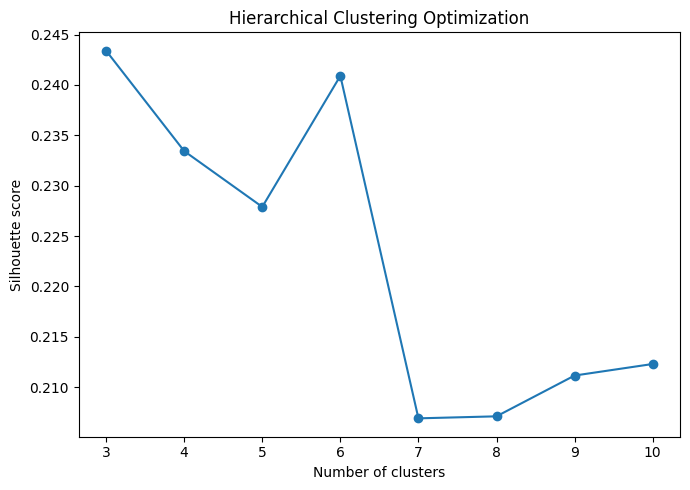

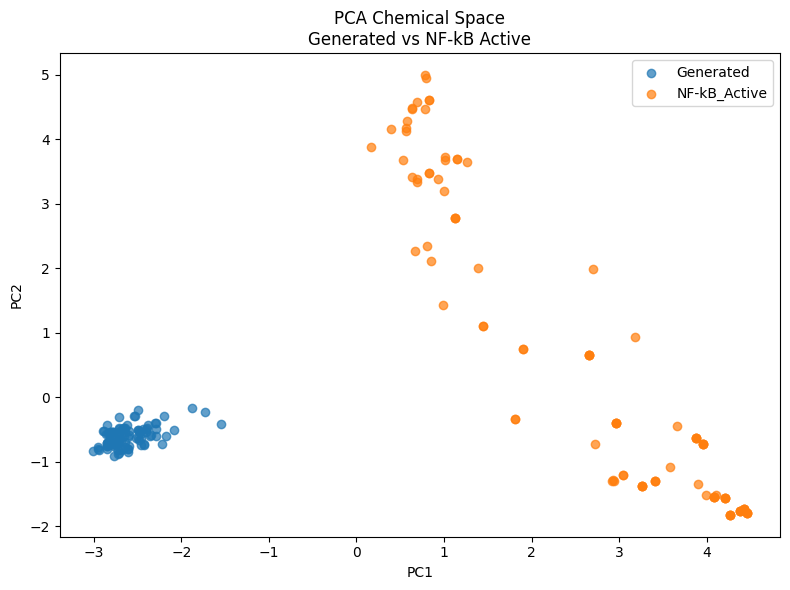

/tmp/ipykernel_809/1809097854.py:677: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z=linkage(


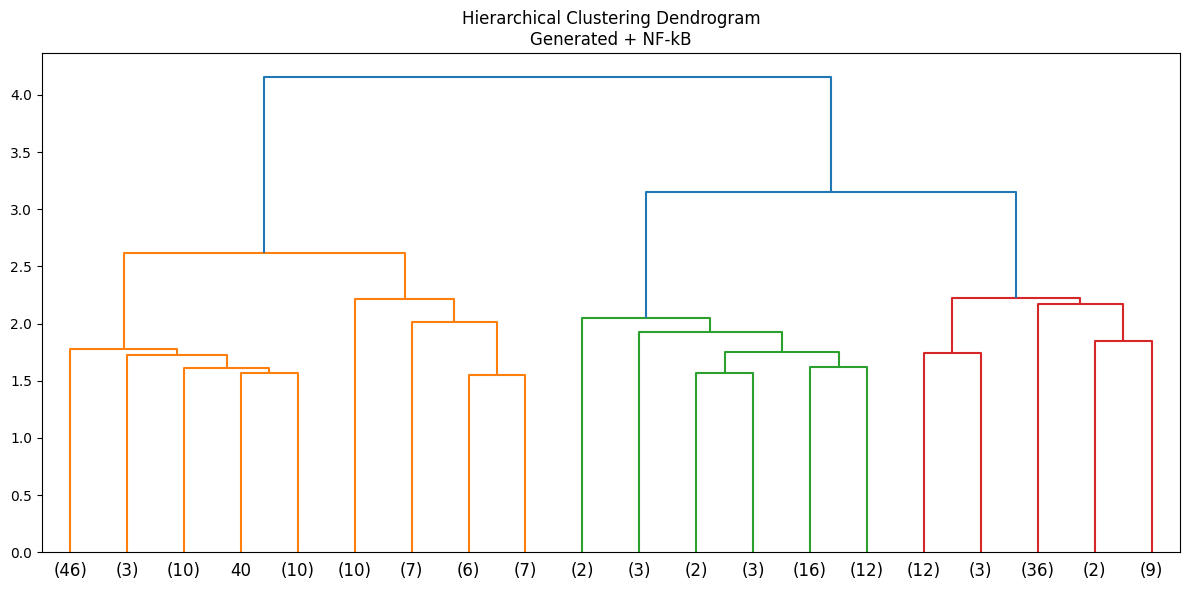


ALL Generated-NFkB RESULTS SAVED IN: Generated_NFkB_results


In [ ]:
# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs NF-kB Active Molecules
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Similarity heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"

NFKB_FILE = "/content/top 100 actives.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_NFkB_results")

OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


nfkb = pd.read_csv(
    NFKB_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



nfkb_smiles = (
    nfkb[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = (
    generated_smiles
    +
    nfkb_smiles
)



sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["NF-kB_Active"] * len(nfkb_smiles)
)



print(
    "Total molecules:",
    len(all_smiles)
)




# ============================================================
# MORGAN FINGERPRINT
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]

valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):


    fp,arr=get_fp(smi)


    if fp is not None:


        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)




X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)




# ============================================================
# TANIMOTO SIMILARITY MATRIX
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )




# ============================================================
# GENERATED vs NF-kB HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


nfkb_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="NF-kB_Active"
]



generated_nfkb_matrix = similarity[
    np.ix_(
        generated_ids,
        nfkb_ids
    )
]




plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_nfkb_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "NF-kB active molecules"
)



plt.ylabel(
    "GFlowNet generated molecules"
)



plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs NF-kB Active Compounds"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_nfkb_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)



plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–NF-kB Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-NFkB PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in nfkb_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "NFkB_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs.xlsx",
    index=False
)



print(
    "Top Generated-NFkB pairs saved"
)




# ============================================================
# TOP PAIR BAR PLOT
# ============================================================


top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "NFkB"
    ]
)



plt.figure(figsize=(10,6))



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)



plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–NF-kB Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )



    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    ).to_excel(
        OUTPUT_DIR/f"Generated_NFkB_clusters_k{k}.xlsx",
        index=False
    )




# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================


pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")



plt.title(
    "PCA Chemical Space\nGenerated vs NF-kB Active"
)



plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_NFkB.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================


Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + NF-kB"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL Generated-NFkB RESULTS SAVED IN:",
    OUTPUT_DIR
)

In [ ]:

!zip -r /content/Generated_FDA_results.zip /content/Generated_FDA_results

  adding: content/Generated_FDA_results/ (stored 0%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k6.xlsx (deflated 5%)
  adding: content/Generated_FDA_results/Generated_FDA_dendrogram.png (deflated 37%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k7.xlsx (deflated 5%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k8.xlsx (deflated 5%)
  adding: content/Generated_FDA_results/Generated_FDA_Tanimoto_heatmap.png (deflated 30%)
  adding: content/Generated_FDA_results/Top_Generated_FDA_pairs_barplot.png (deflated 33%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k3.xlsx (deflated 5%)
  adding: content/Generated_FDA_results/Generated_FDA_similarity_distribution.png (deflated 28%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k9.xlsx (deflated 5%)
  adding: content/Generated_FDA_results/PCA_Generated_FDA.png (deflated 14%)
  adding: content/Generated_FDA_results/Generated_FDA_clusters_k5.xlsx (deflated 5%

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install rdkit minisom openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 50.3 MB/s eta 0:00:00
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=4ef8364b90c26cc36c6c40fdab7d329ffde28b0efc5b54520d1a5d0426470fff
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
from rdkit import Chem
print("RDKit installed correctly")

RDKit installed correctly


Total molecules: 200
Valid molecules: 200


[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerator
[23:20:00] DEPRECATION WARNING: please use MorganGenerat

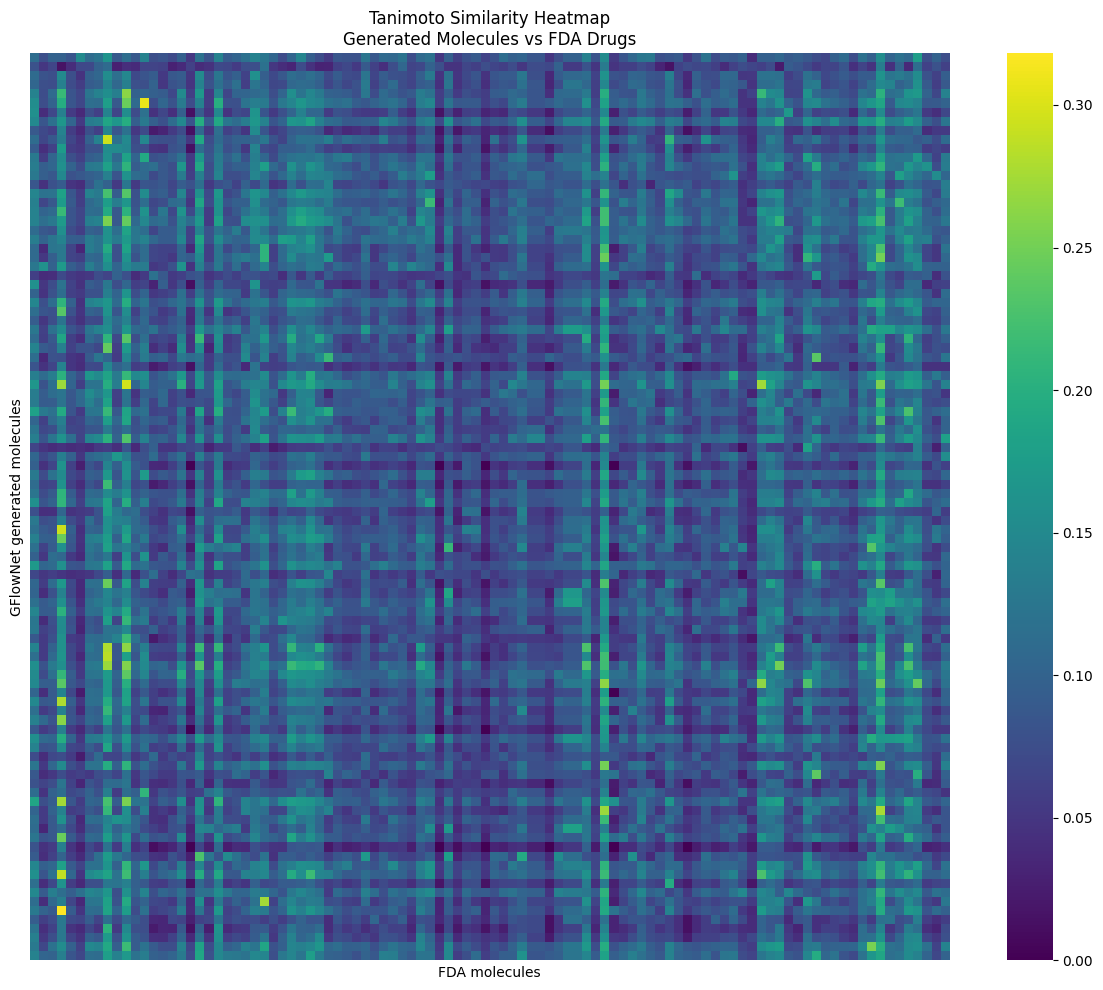

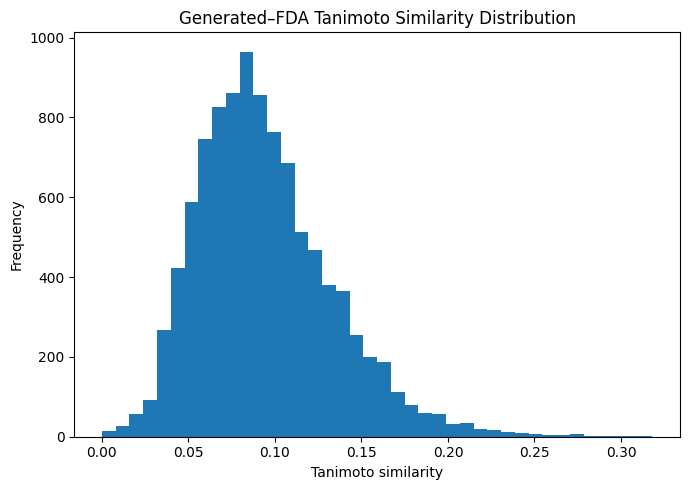

Top similarity pairs saved


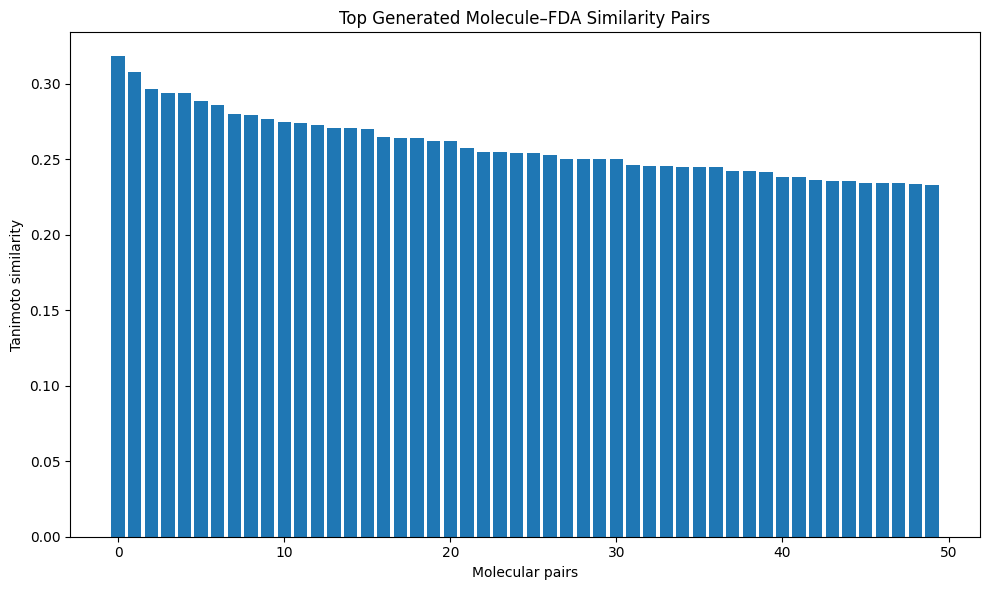

k= 3 Silhouette= 0.04863967969194901
k= 4 Silhouette= 0.06270028014481804
k= 5 Silhouette= 0.06027674781765311
k= 6 Silhouette= 0.05802183269328756
k= 7 Silhouette= 0.06614225804019971
k= 8 Silhouette= 0.07735213911902228
k= 9 Silhouette= 0.07402085748385573
k= 10 Silhouette= 0.07462339223282922


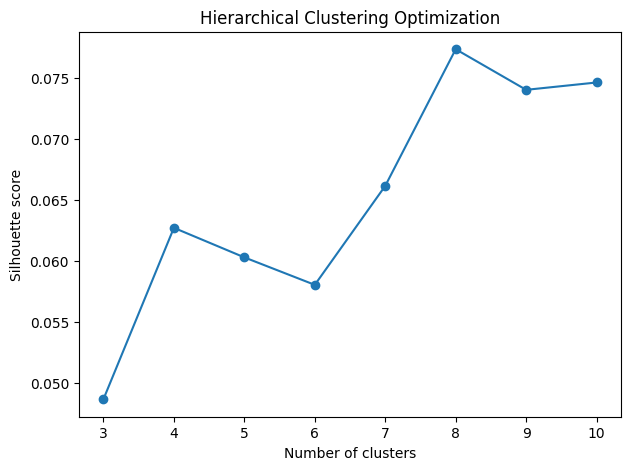

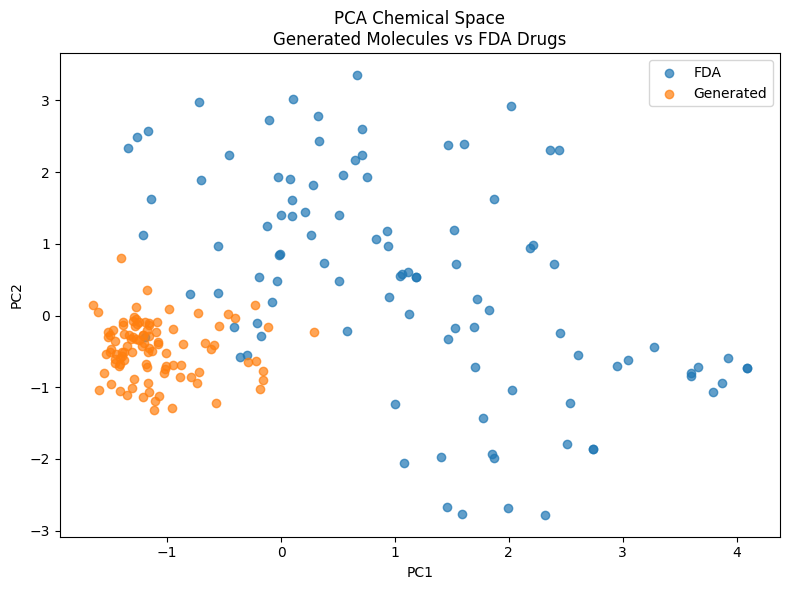

/tmp/ipykernel_886/22362785.py:655: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z=linkage(


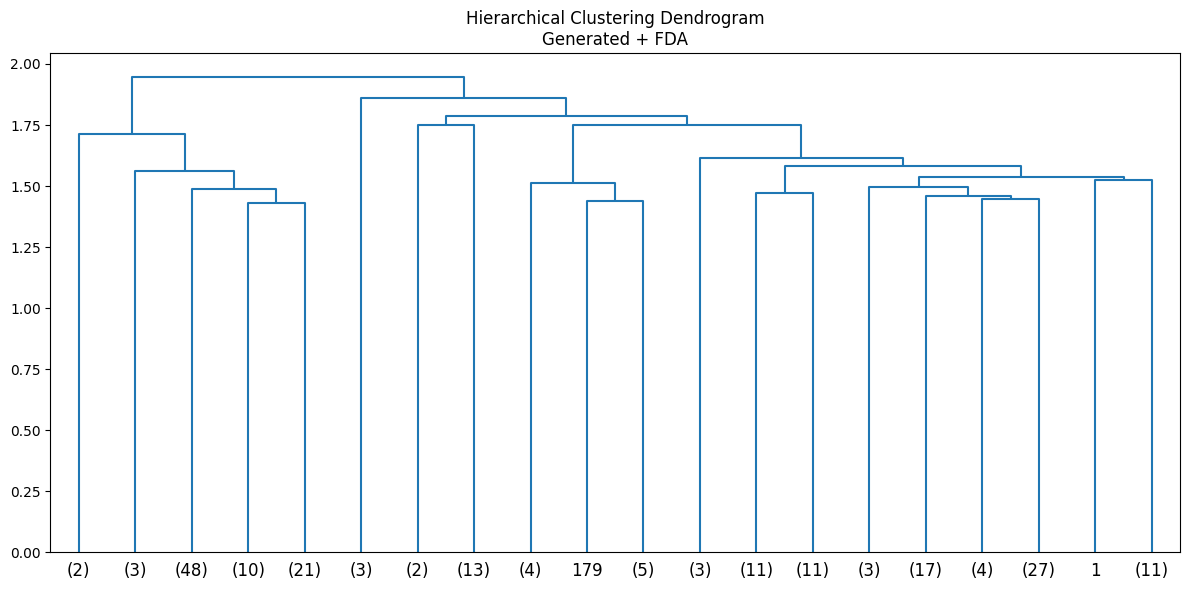


ALL GENERATED-FDA RESULTS SAVED IN: Generated_FDA_results


In [ ]:
# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs FDA Drugs
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"
FDA_FILE = "/content/TOP100 FDA.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_FDA_results")
OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


fda = pd.read_csv(
    FDA_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)


fda_smiles = (
    fda[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = generated_smiles + fda_smiles


sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["FDA"] * len(fda_smiles)
)



print("Total molecules:",len(all_smiles))



# ============================================================
# MORGAN FINGERPRINT GENERATION
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]
valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):

    fp,arr=get_fp(smi)


    if fp is not None:

        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)



X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)



# ============================================================
# Tanimoto Similarity Matrix
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )



# ============================================================
# GENERATED vs FDA HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


fda_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="FDA"
]



generated_fda_matrix = similarity[
    np.ix_(
        generated_ids,
        fda_ids
    )
]



plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_fda_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "FDA molecules"
)


plt.ylabel(
    "GFlowNet generated molecules"
)


plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs FDA Drugs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_fda_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)


plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–FDA Tanimoto Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-FDA SIMILARITY PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in fda_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "FDA_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_FDA_pairs.xlsx",
    index=False
)



print(
    "Top similarity pairs saved"
)




# ============================================================
# TOP PAIRS BAR GRAPH
# ============================================================



top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "FDA"
    ]
)



plt.figure(
    figsize=(10,6)
)



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)


plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–FDA Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_FDA_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )


    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    cluster_df=pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    )



    cluster_df.to_excel(
        OUTPUT_DIR/f"Generated_FDA_clusters_k{k}.xlsx",
        index=False
    )



# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================



pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")


plt.title(
    "PCA Chemical Space\nGenerated Molecules vs FDA Drugs"
)


plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_FDA.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================



Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + FDA"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL GENERATED-FDA RESULTS SAVED IN:",
    OUTPUT_DIR
)